# Association Rule Mining — Lifecycle, Fragility & Held-Out Evaluation

**Dataset:** Online Retail II (UCI) | **Period:** Dec 2009 – Dec 2010 (13 months)

**Research Question:** Can association rules be classified into lifecycle types (persistent, declining, emerging, seasonal) over a 13-month period, and can cancellation-basket mining reveal *fragile* rules — compared between domestic (UK) and export markets?

**Sub-Questions:**
- **Q1.** What proportion of rules are persistent vs declining vs emerging vs seasonal, and how does this composition vary across months?
- **Q2.** Which strong rules have the highest cancellation co-occurrence rates, and do fragile rules share identifiable characteristics?
- **Q3.** Do association rules generalise out-of-sample? Is lift a reliable proxy for held-out relevance?

---






## 1 · Install Dependencies

In [1]:
!pip install mlxtend scikit-learn openpyxl seaborn scipy -q
print("✓ All packages ready.")

✓ All packages ready.


## 2 · Imports

In [2]:
import os, time, warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from mlxtend.frequent_patterns import fpgrowth, association_rules
from scipy.stats import chi2_contingency, wilcoxon, mannwhitneyu, spearmanr
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.float_format', '{:.6f}'.format)

TOTAL_START = time.time()
print("✓ All imports successful.")

✓ All imports successful.


## 3 · Configuration


In [3]:
# ── File ─────────────────────────────────────────────────────────────
FILE_PATH = 'online_retail_II.xlsx'

# ── FP-Growth ────────────────────────────────────────────────────────
MIN_PRODUCT_FREQ = 10    # drop products in < this many invoices
MIN_SUPPORT      = 0.01  # FP-Growth minimum support
MIN_LIFT         = 1.5   # minimum lift for rule generation
MIN_CONFIDENCE   = 0.50  # minimum confidence

# ── Lifecycle Classification Thresholds ──────────────────────────────
LC_ACTIVE_THRESH  = 0.80   # active in ≥80% of months → persistent
LC_TREND_MULT     = 1.50   # 2nd-half mean > 1.5× 1st-half → emerging
LC_DECLINE_FRAC   = 0.70   # 2nd-half mean < 0.7× 1st-half → declining
LC_CV_THRESH      = 0.60   # CV > 0.6 → seasonal
LC_SPORADIC_CUTOFF= 0.60   # active in <60% of months & no trend → sporadic

# ── Sensitivity grid for threshold robustness check ──────────────────
LC_SENSITIVITY_GRID = {
    'LC_ACTIVE_THRESH':   [0.70, 0.75, 0.80, 0.85, 0.90],
    'LC_CV_THRESH':       [0.50, 0.55, 0.60, 0.65, 0.70],
    'LC_SPORADIC_CUTOFF': [0.50, 0.55, 0.60, 0.65, 0.70],
}

# ── Rolling-window hold-out evaluation ───────────────────────────────
# Mine on TRAIN_MONTHS; evaluate rule stability on EVAL_MONTHS.
TRAIN_MONTHS = 10   # first N months → training basket
EVAL_MONTHS  = 3    # last N months  → held-out evaluation

# ── Statistical ──────────────────────────────────────────────────────
CRAMERS_V_MIN    = 0.10
FRAGILITY_PCTILE = 90

if not os.path.exists(FILE_PATH):
    try:
        from google.colab import files
        print(f"Upload '{FILE_PATH}':")
        uploaded = files.upload()
        if FILE_PATH not in uploaded and len(uploaded) == 1:
            FILE_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"Place '{FILE_PATH}' in the working directory.")

print("✓ Configuration ready.")
print(f"  FILE_PATH         = {FILE_PATH}")
print(f"  MIN_SUPPORT       = {MIN_SUPPORT}  |  MIN_LIFT = {MIN_LIFT}  |  MIN_CONFIDENCE = {MIN_CONFIDENCE}")
print(f"  TRAIN_MONTHS      = {TRAIN_MONTHS}  |  EVAL_MONTHS = {EVAL_MONTHS}")
print(f"  LC_ACTIVE_THRESH  = {LC_ACTIVE_THRESH}  (persistent threshold)")
print(f"  CRAMERS_V_MIN     = {CRAMERS_V_MIN}  (effect-size filter, not p-value)")

✓ Configuration ready.
  FILE_PATH         = online_retail_II.xlsx
  MIN_SUPPORT       = 0.01  |  MIN_LIFT = 1.5  |  MIN_CONFIDENCE = 0.5
  TRAIN_MONTHS      = 10  |  EVAL_MONTHS = 3
  LC_ACTIVE_THRESH  = 0.8  (persistent threshold)
  CRAMERS_V_MIN     = 0.1  (effect-size filter, not p-value)


## 4 · Data Loading & Cleaning



In [4]:
df = pd.read_excel(FILE_PATH)
df = df.dropna(subset=['Invoice', 'StockCode', 'Quantity'])
df['Invoice']     = df['Invoice'].astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Separate cancellations BEFORE filtering
df_cancel = df[df['Invoice'].str.startswith('C')].copy()
df        = df[~df['Invoice'].str.startswith('C')].copy()
df        = df[df['Quantity'] > 0]
df['YearMonth'] = df['InvoiceDate'].dt.strftime('%Y-%m')

# Ensure df_cancel has YearMonth too
df_cancel['YearMonth'] = pd.to_datetime(df_cancel['InvoiceDate']).dt.strftime('%Y-%m')

# ── Handle StockCode → Description collisions ────────────────────────
# A StockCode may have multiple descriptions across rows (data-entry variants).
# Keep the most frequent description per StockCode to avoid arbitrary assignment.
desc_counts = (
    df.dropna(subset=['Description'])
      .groupby(['StockCode', 'Description'])
      .size()
      .reset_index(name='n')
)
product_map = (
    desc_counts.sort_values('n', ascending=False)
               .drop_duplicates('StockCode')
               .set_index('StockCode')['Description']
               .to_dict()
)
n_collision = (desc_counts.groupby('StockCode')['Description'].nunique() > 1).sum()
print(f"StockCodes with multiple descriptions (collisions): {n_collision}")
print(f"  → resolved by keeping most-frequent description per StockCode")

def get_name(codes):
    parts = []
    for c in codes:
        name = str(product_map.get(c, c))
        parts.append(name[:35] + ('…' if len(name) > 35 else ''))
    return ' + '.join(parts)

# Remove rare products
product_invoice_counts = df.groupby('StockCode')['Invoice'].nunique()
valid_products         = product_invoice_counts[product_invoice_counts >= MIN_PRODUCT_FREQ].index
df                     = df[df['StockCode'].isin(valid_products)]

print(f"Purchase transactions  : {len(df):,}")
print(f"Cancellation rows      : {len(df_cancel):,}")
print(f"Products after filter  : {df['StockCode'].nunique():,}  (removed {(~product_invoice_counts.index.isin(valid_products)).sum()} with < {MIN_PRODUCT_FREQ} invoices)")
print(f"Unique invoices        : {df['Invoice'].nunique():,}")
print(f"Date range             : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head(3)

StockCodes with multiple descriptions (collisions): 481
  → resolved by keeping most-frequent description per StockCode
Purchase transactions  : 509,467
Cancellation rows      : 10,206
Products after filter  : 3,437  (removed 880 with < 10 invoices)
Unique invoices        : 21,810
Date range             : 2009-12-01 → 2010-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950000,13085.000000,United Kingdom,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom,2009-12


## 5 · Basket Encoding

Each row = one invoice; each column = one product; value = 1 if purchased.

In [5]:
basket = (
    df.groupby(['Invoice', 'StockCode'])['Quantity']
      .sum().unstack(fill_value=0)
)
basket      = (basket > 0).astype('uint8')
basket_bool = basket.astype(bool)

print(f"Basket shape : {basket.shape[0]:,} invoices × {basket.shape[1]:,} products")
print(f"Density      : {basket.values.mean():.4%}  (fraction of 1s)")
basket.head(3)

Basket shape : 21,810 invoices × 3,437 products
Density      : 0.6621%  (fraction of 1s)


StockCode,10002,10120,10125,10133,10134,10135,10138,11001,15030,15034,...,DCGS0076,DCGSSBOY,DCGSSGIRL,DOT,M,PADS,POST,TEST001,gift_0001_20,gift_0001_30
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 6 · FP-Growth & Rule Generation (with Train/Hold-Out Split)



In [6]:
months_all     = sorted(df['YearMonth'].unique())
n_months_all   = len(months_all)

# ── Rolling-window train / held-out split ────────────────────────────
if TRAIN_MONTHS is not None and TRAIN_MONTHS < n_months_all:
    train_months = months_all[:TRAIN_MONTHS]
    eval_months  = months_all[TRAIN_MONTHS:]
    df_train     = df[df['YearMonth'].isin(train_months)]
    df_eval      = df[df['YearMonth'].isin(eval_months)]
    print(f"Train months : {train_months[0]} → {train_months[-1]}  ({len(train_months)} months)")
    print(f"Eval  months : {eval_months[0]}  → {eval_months[-1]}   ({len(eval_months)} months)")
else:
    train_months = months_all
    df_train     = df
    df_eval      = None
    print("No hold-out split (TRAIN_MONTHS = None or covers full period).")

basket_train = (
    df_train.groupby(['Invoice', 'StockCode'])['Quantity']
            .sum().unstack(fill_value=0)
)
basket_train = (basket_train > 0).astype('uint8')

# Global basket (for Cramér's V on full data)
basket = (
    df.groupby(['Invoice', 'StockCode'])['Quantity']
      .sum().unstack(fill_value=0)
)
basket      = (basket > 0).astype('uint8')
basket_bool = basket.astype(bool)

print(f"\nBasket shape (train) : {basket_train.shape[0]:,} invoices × {basket_train.shape[1]:,} products")
print(f"Density (train)      : {basket_train.values.mean():.4%}")

freq_items = fpgrowth(basket_train, min_support=MIN_SUPPORT, use_colnames=True)
rules = association_rules(freq_items, metric='lift', min_threshold=MIN_LIFT, num_itemsets=len(freq_items))
rules = rules[rules['confidence'] >= MIN_CONFIDENCE].copy()
rules = rules[['antecedents','consequents','support','confidence',
                'lift','leverage','conviction','antecedent support','consequent support']]

rules['antecedents'] = rules['antecedents'].apply(tuple)
rules['consequents'] = rules['consequents'].apply(tuple)
rules = rules.reset_index(drop=True)
rules['ante_name'] = rules['antecedents'].apply(get_name)
rules['cons_name'] = rules['consequents'].apply(get_name)

print(f"Frequent itemsets : {len(freq_items):,}")
print(f"Association rules : {len(rules):,}  (confidence ≥ {MIN_CONFIDENCE} & lift ≥ {MIN_LIFT})")
print("\nTop 10 rules by lift:")
display(
    rules.sort_values('lift', ascending=False)
         [['ante_name','cons_name','support','confidence','lift']]
         .head(10)
)

Train months : 2009-12 → 2010-09  (10 months)
Eval  months : 2010-10  → 2010-12   (3 months)

Basket shape (train) : 15,706 invoices × 3,327 products
Density (train)      : 0.6613%
Frequent itemsets : 1,287
Association rules : 359  (confidence ≥ 0.5 & lift ≥ 1.5)

Top 10 rules by lift:


,ante_name,cons_name,support,confidence,lift
349,CHILDS GARDEN TROWEL PINK,CHILDS GARDEN FORK PINK,0.010569,0.768519,67.810965
350,CHILDS GARDEN FORK PINK,CHILDS GARDEN TROWEL PINK,0.010569,0.932584,67.810965
347,CHILDS GARDEN TROWEL BLUE,CHILDS GARDEN TROWEL PINK,0.011588,0.862559,62.719238
348,CHILDS GARDEN TROWEL PINK,CHILDS GARDEN TROWEL BLUE,0.011588,0.842593,62.719238
138,GREEN SPOTTY CUP,BLUE SPOTTY CUP + RED SPOTTY CUP,0.010124,0.636000,41.970655
136,BLUE SPOTTY CUP + RED SPOTTY CUP,GREEN SPOTTY CUP,0.010124,0.668067,41.970655
358,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.010951,0.627737,38.066567
357,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.010951,0.664093,38.066567
117,COFFEE MUG DOG + BALL DESIGN,COFFEE MUG CAT + BIRD DESIGN,0.012034,0.732558,37.847231
118,COFFEE MUG CAT + BIRD DESIGN,COFFEE MUG DOG + BALL DESIGN,0.012034,0.621711,37.847231


## 7 · Rule Enrichment — Conviction, Zhang's Metric & Kulczynski

Beyond lift, we compute three additional interestingness measures:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Conviction** | (1 − P(C)) / (1 − conf) | Directional dependence; ∞ = perfect rule |
| **Zhang's metric** | (P(A∩B) − P(A)P(B)) / max(...) | Range [−1,1]; 0 = independent |
| **Kulczynski** | ½(P(B\|A) + P(A\|B)) | Symmetric; robust to support asymmetry |

> **Why multiple metrics?** Lift is symmetric and inflated for low-support items.
> Conviction captures *directional* strength, Zhang's penalises spurious co-occurrence,
> and Kulczynski is robust to support asymmetry. Together they cross-check lift.

In [7]:
# Conviction already in mlxtend output — clip Inf for display
rules['conviction'] = rules['conviction'].replace([np.inf], 999.0)

# Zhang's metric
_num   = rules['support'].values - rules['antecedent support'].values * rules['consequent support'].values
_denom = np.maximum(
    rules['support'].values * (1 - rules['antecedent support'].values) * (1 - rules['consequent support'].values),
    rules['antecedent support'].values * rules['consequent support'].values * (1 - rules['support'].values)
)
rules['zhang'] = np.where(_denom == 0, np.nan, _num / _denom)

# Kulczynski coefficient
rules['kulczynski'] = 0.5 * (
    rules['confidence'] +
    rules['support'] / rules['consequent support'].replace(0, np.nan)
)

print("Extended rule metrics computed:")
print(rules[['support','confidence','lift','conviction','zhang','kulczynski']]
      .describe().round(4))

Extended rule metrics computed:
         support  confidence       lift  conviction      zhang  kulczynski
count 359.000000  359.000000 359.000000  359.000000 359.000000  359.000000
mean    0.013800    0.620200  15.662800    2.718700   0.985300    0.475000
std     0.004800    0.090400  10.014400    1.115400   0.026100    0.101000
min     0.010100    0.500000   3.178300    1.693800   0.831500    0.284500
25%     0.010800    0.546600   8.798900    2.098400   0.976300    0.398000
50%     0.012000    0.601500  11.940200    2.365500   0.989700    0.449400
75%     0.014600    0.683300  20.767000    3.002400   1.002000    0.525900
max     0.038300    0.932600  67.811000   14.629300   1.025900    0.852600


## 8 · Month Coverage Validation

In [8]:
months_available = sorted(df['YearMonth'].unique())
n_months         = len(months_available)
print(f"Months available : {months_available}")
print(f"Total months     : {n_months}")
assert n_months >= 13, "WARNING: fewer than 13 months — lifecycle labels may be unreliable."
print("✓ Full 13-month period confirmed.")

Months available : ['2009-12', '2010-01', '2010-02', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12']
Total months     : 13
✓ Full 13-month period confirmed.


## 9 · Monthly Support Tracking

In [9]:
def fast_support(basket_data, items):
    """Support of an itemset; returns 0.0 if any column is absent."""
    cols = [c for c in items if c in basket_data.columns]
    if len(cols) != len(items):
        return 0.0
    return float(basket_data[cols].all(axis=1).sum()) / len(basket_data)

# Build per-month baskets
monthly_baskets = {}
for month, group in df.groupby('YearMonth'):
    bm = group.groupby(['Invoice','StockCode'])['Quantity'].sum().unstack(fill_value=0)
    monthly_baskets[month] = (bm > 0).astype('uint8')

# Track support per rule per month
monthly_support = defaultdict(dict)
for month in months_available:
    bm = monthly_baskets[month]
    for idx, row in rules.iterrows():
        items = list(set(row['antecedents']) | set(row['consequents']))
        monthly_support[idx][month] = fast_support(bm, items)

print(f"✓ Monthly support tracking complete.")
print(f"  Months cached : {len(monthly_baskets)}")
print(f"  Rules tracked : {len(rules)}")

✓ Monthly support tracking complete.
  Months cached : 13
  Rules tracked : 359


## 10 · Lifecycle Classification (Survivorship-Bias Corrected)



In [10]:
# Step 1 — mine early rules
early_months = months_available[:6]
df_early     = df[df['YearMonth'].isin(early_months)]
basket_early = (df_early.groupby(['Invoice','StockCode'])['Quantity']
                          .sum().unstack(fill_value=0))
basket_early = (basket_early > 0).astype('uint8')

fi_early    = fpgrowth(basket_early, min_support=MIN_SUPPORT, use_colnames=True)
rules_early = association_rules(fi_early, metric='lift', min_threshold=MIN_LIFT, num_itemsets=len(fi_early))
rules_early = rules_early[rules_early['confidence'] >= MIN_CONFIDENCE]
rules_early['antecedents'] = rules_early['antecedents'].apply(tuple)
rules_early['consequents'] = rules_early['consequents'].apply(tuple)

global_keys   = set(zip(rules['antecedents'], rules['consequents']))
early_keys    = set(zip(rules_early['antecedents'], rules_early['consequents']))
declined_keys = early_keys - global_keys

print(f"Rules mined from first 6 months : {len(rules_early)}")
print(f"Rules in global set             : {len(rules)}")
print(f"Early-only (declining) rules    : {len(declined_keys)}")

# Step 2 — build declined-rule rows
declined_records = []
for i, row in rules_early.iterrows():
    k = (row['antecedents'], row['consequents'])
    if k in declined_keys:
        declined_records.append({
            'antecedents': row['antecedents'], 'consequents': row['consequents'],
            'support': row['support'], 'confidence': row['confidence'], 'lift': row['lift'],
            'leverage': row.get('leverage', 0), 'conviction': row.get('conviction', 1),
            'antecedent support': row.get('antecedent support', 0),
            'consequent support': row.get('consequent support', 0),
            'zhang': 0.0, 'kulczynski': 0.5,
            'ante_name': get_name(row['antecedents']),
            'cons_name': get_name(row['consequents']),
        })

if declined_records:
    df_declined = pd.DataFrame(declined_records)
    for rec_i, rec in enumerate(declined_records):
        orig_idx = len(rules) + rec_i
        for month in months_available:
            bm = monthly_baskets[month]
            items = list(set(rec['antecedents']) | set(rec['consequents']))
            monthly_support[orig_idx][month] = fast_support(bm, items)
    rules = pd.concat([rules, df_declined], ignore_index=True)

declined_indices = set(range(len(rules) - len(declined_records), len(rules)))

# Step 3 — classify
def classify_rule(series, idx):
    if idx in declined_indices:
        return 'declining'
    v   = np.array([series.get(m, 0) for m in months_available])
    ar  = (v > 0.005).mean()
    if ar >= LC_ACTIVE_THRESH:
        return 'persistent'
    mid = len(v) // 2
    f, s = v[:mid].mean(), v[mid:].mean()
    if f > 0 and s > f * LC_TREND_MULT:
        return 'emerging'
    if f > 0 and s < f * LC_DECLINE_FRAC:
        return 'declining'
    cv = np.std(v) / (np.mean(v) + 1e-6)
    if cv > LC_CV_THRESH:
        return 'seasonal'
    if ar < LC_SPORADIC_CUTOFF:
        return 'sporadic'
    return 'persistent'

rules['lifecycle'] = [classify_rule(monthly_support[idx], idx) for idx in rules.index]

lc_dist = rules['lifecycle'].value_counts().rename_axis('lifecycle').to_frame('count')
lc_dist['proportion'] = (lc_dist['count'] / len(rules)).round(4)
print(f"\nTotal rules after adding declined : {len(rules)}")
print("\nLifecycle distribution (survivorship-bias corrected):")
display(lc_dist)

Rules mined from first 6 months : 346
Rules in global set             : 359
Early-only (declining) rules    : 120

Total rules after adding declined : 479

Lifecycle distribution (survivorship-bias corrected):


,count,proportion
lifecycle,,
persistent,309,0.645100
declining,128,0.267200
emerging,23,0.048000
seasonal,19,0.039700


## 11 · Statistical Validation — Cramér's V (Effect Size)



In [11]:
def chi_square_cramers_v(rule):
    ante_cols = [c for c in rule['antecedents'] if c in basket_bool.columns]
    cons_cols = [c for c in rule['consequents'] if c in basket_bool.columns]
    if len(ante_cols) != len(rule['antecedents']) or len(cons_cols) != len(rule['consequents']):
        return pd.Series({'p_value': 1.0, 'cramers_v': 0.0})
    cols_A = basket_bool[ante_cols].all(axis=1)
    cols_B = basket_bool[cons_cols].all(axis=1)
    table = np.array([
        [int((cols_A & cols_B).sum()),  int((cols_A & ~cols_B).sum())],
        [int((~cols_A & cols_B).sum()), int((~cols_A & ~cols_B).sum())],
    ])
    try:
        chi2, p, _, _ = chi2_contingency(table)
        n = table.sum()
        v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    except Exception:
        p, v = 1.0, 0.0
    return pd.Series({'p_value': p, 'cramers_v': v})

chi_results        = rules.apply(chi_square_cramers_v, axis=1)
rules['p_value']   = chi_results['p_value']
rules['cramers_v'] = chi_results['cramers_v']
rules['significant_pval']    = rules['p_value'] < 0.05
rules['significant_effect']  = rules['cramers_v'] >= CRAMERS_V_MIN   # primary filter

print(f"Total rules            : {len(rules)}")
print(f"p < 0.05               : {rules['significant_pval'].sum()} / {len(rules)}  ← inflated at large n")
print(f"Cramér's V ≥ {CRAMERS_V_MIN}       : {rules['significant_effect'].sum()} / {len(rules)}  ← primary filter")
print(f"\nCramér's V summary:")
display(rules['cramers_v'].describe().round(4).to_frame())

Total rules            : 479
p < 0.05               : 479 / 479  ← inflated at large n
Cramér's V ≥ 0.1       : 479 / 479  ← primary filter

Cramér's V summary:


,cramers_v
count,479.000000
mean,0.451700
std,0.165900
min,0.129700
25%,0.321800
50%,0.418000
75%,0.553500
max,0.916800


## 12 · Global Support for All Rules

In [12]:
rules['global_support'] = [
    fast_support(basket, list(set(rules.loc[idx,'antecedents']) | set(rules.loc[idx,'consequents'])))
    for idx in rules.index
]
print("✓ Global support computed.")
print(rules[['support','global_support']].describe().round(6))

✓ Global support computed.
         support  global_support
count 479.000000      479.000000
mean    0.013225        0.011876
std     0.004440        0.004746
min     0.010060        0.004264
25%     0.010633        0.009262
50%     0.011588        0.010591
75%     0.014074        0.013044
max     0.038329        0.036497


## 13 · Cancellation-Basket Fragility

**Definition:**
$$\text{fragility}(A \Rightarrow C) = \frac{\text{cancellation baskets containing } A \cup C}{\text{purchase baskets containing } A \cup C}$$

A high fragility rate indicates customers frequently cancel the exact bundle,
suggesting the rule is behaviourally unstable.



In [13]:
purchase_sets = df.groupby('Invoice')['StockCode'].apply(frozenset)
cancel_sets   = df_cancel.groupby('Invoice')['StockCode'].apply(frozenset).tolist()

# ── Global fragility ────────────────────────────────────────────────
def fragility_rate(ant, con):
    items = set(ant) | set(con)
    n_purchase = sum(1 for s in purchase_sets if items.issubset(s))
    n_cancel   = sum(1 for s in cancel_sets   if items.issubset(s))
    return n_cancel / n_purchase if n_purchase > 0 else 0.0

rules['fragility'] = [fragility_rate(a, b)
                      for a, b in zip(rules['antecedents'], rules['consequents'])]
rules.loc[rules['global_support'] < MIN_SUPPORT, 'fragility'] = 0.0

# ── Per-month fragility CV (denominator instability check) ──────────
monthly_purchase_sets = {m: df[df['YearMonth']==m].groupby('Invoice')['StockCode'].apply(frozenset)
                         for m in sorted(df['YearMonth'].unique())}
monthly_cancel_sets   = {m: df_cancel[df_cancel['YearMonth']==m].groupby('Invoice')['StockCode'].apply(frozenset).tolist()
                         for m in sorted(df['YearMonth'].unique())}

def monthly_fragility_cv(ant, con):
    """CV of per-month fragility rates — high CV = denominator instability."""
    items = set(ant) | set(con)
    monthly_rates = []
    for m in sorted(df['YearMonth'].unique()):
        psets = monthly_purchase_sets.get(m, pd.Series([], dtype=object))
        csets = monthly_cancel_sets.get(m, [])
        np_ = sum(1 for s in psets if items.issubset(s))
        nc_ = sum(1 for s in csets if items.issubset(s))
        if np_ > 0:
            monthly_rates.append(nc_ / np_)
    if len(monthly_rates) < 2:
        return np.nan
    return np.std(monthly_rates) / (np.mean(monthly_rates) + 1e-9)

# Compute for a sample of high-support rules to keep runtime reasonable
sample_n = min(50, len(rules))
high_sup_idx = rules[rules['global_support'] > MIN_SUPPORT].index[:sample_n]
frag_cvs = {idx: monthly_fragility_cv(rules.loc[idx,'antecedents'], rules.loc[idx,'consequents'])
            for idx in high_sup_idx}
rules['fragility_cv'] = pd.Series(frag_cvs)

cv_summary = rules['fragility_cv'].describe()
high_instability = (rules['fragility_cv'] > 1.0).sum()
print("Per-month fragility denominator instability (CV across months):")
display(cv_summary.round(4).to_frame())
print(f"Rules with CV > 1.0 (high instability) : {high_instability}")
print("  → High-CV rules should be treated as unreliable fragility estimates.")

q_frag = rules['fragility'].quantile(FRAGILITY_PCTILE / 100)
rules['is_fragile'] = rules['fragility'] >= q_frag

print(f"\nFragility summary:")
display(rules['fragility'].describe().round(6).to_frame())
print(f"\n{FRAGILITY_PCTILE}th-pctile threshold : {q_frag:.6f}")
print(f"Fragile rules         : {rules['is_fragile'].sum()}")

Per-month fragility denominator instability (CV across months):


,fragility_cv
count,50.000000
mean,1.525800
std,1.451400
min,0.000000
25%,0.000000
50%,1.637300
75%,3.090600
max,3.464100


Rules with CV > 1.0 (high instability) : 28
  → High-CV rules should be treated as unreliable fragility estimates.

Fragility summary:


,fragility
count,479.000000
mean,0.002573
std,0.007566
min,0.000000
25%,0.000000
50%,0.000000
75%,0.003676
max,0.136170



90th-pctile threshold : 0.006983
Fragile rules         : 48


## 14 · Domestic vs Export Support & Fragility (Wilcoxon + Mann-Whitney U)

In [14]:
def build_basket(data):
    b = data.groupby(['Invoice','StockCode'])['Quantity'].sum().unstack(fill_value=0)
    return (b > 0).astype('uint8')

basket_dom = build_basket(df[df['Country'] == 'United Kingdom'])
basket_exp = build_basket(df[df['Country'] != 'United Kingdom'])

rules['support_domestic'] = [fast_support(basket_dom, list(set(a)|set(b)))
                              for a,b in zip(rules['antecedents'],rules['consequents'])]
rules['support_export']   = [fast_support(basket_exp, list(set(a)|set(b)))
                              for a,b in zip(rules['antecedents'],rules['consequents'])]

# Wilcoxon test (support)
d, e = rules['support_domestic'].values, rules['support_export'].values
nzm = (d - e) != 0
stat_w, p_w = wilcoxon(d[nzm], e[nzm]) if nzm.sum() > 20 else (np.nan, np.nan)
print(f"Wilcoxon support dom vs export")
print(f"  Statistic : {stat_w:.2f}")
print(f"  p-value   : {p_w:.4f}  → {'Significant' if p_w < 0.05 else 'Not significant'} (α=0.05)")

# Market-level fragility
psets_dom = df[df['Country']=='United Kingdom'].groupby('Invoice')['StockCode'].apply(frozenset)
csets_dom = df_cancel[df_cancel['Country']=='United Kingdom'].groupby('Invoice')['StockCode'].apply(frozenset).tolist()
psets_exp = df[df['Country']!='United Kingdom'].groupby('Invoice')['StockCode'].apply(frozenset)
csets_exp = df_cancel[df_cancel['Country']!='United Kingdom'].groupby('Invoice')['StockCode'].apply(frozenset).tolist()

def frag_mkt(ant, con, psets, csets):
    items = set(ant)|set(con)
    n_p = sum(1 for s in psets if items.issubset(s))
    n_c = sum(1 for s in csets if items.issubset(s))
    return n_c/n_p if n_p > 0 else 0.0

rules['fragility_domestic'] = [frag_mkt(a,b,psets_dom,csets_dom)
                                for a,b in zip(rules['antecedents'],rules['consequents'])]
rules['fragility_export']   = [frag_mkt(a,b,psets_exp,csets_exp)
                                for a,b in zip(rules['antecedents'],rules['consequents'])]

# Mann-Whitney U (fragility)
stat_mw, p_mw = mannwhitneyu(rules['fragility_domestic'], rules['fragility_export'],
                              alternative='two-sided')
print(f"\nMann-Whitney U fragility dom vs export")
print(f"  Statistic : {stat_mw:.2f}")
print(f"  p-value   : {p_mw:.4f}  → {'Significant' if p_mw < 0.05 else 'Not significant'} (α=0.05)")

print("\nMean fragility by lifecycle — Domestic vs Export:")
display(rules.groupby('lifecycle')[['fragility_domestic','fragility_export']].mean().round(6))

Wilcoxon support dom vs export
  Statistic : 53096.00
  p-value   : 0.1481  → Not significant (α=0.05)

Mann-Whitney U fragility dom vs export
  Statistic : 150798.00
  p-value   : 0.0000  → Significant (α=0.05)

Mean fragility by lifecycle — Domestic vs Export:


,fragility_domestic,fragility_export
lifecycle,,
declining,0.011239,0.010375
emerging,0.003036,0.005966
persistent,0.003076,0.007854
seasonal,0.008468,0.004785


## 15 · Held-Out Evaluation — Rolling-Window Generalisation



In [15]:
if df_eval is not None and len(df_eval) > 0:
    basket_eval = (
        df_eval.groupby(['Invoice', 'StockCode'])['Quantity']
               .sum().unstack(fill_value=0)
    )
    basket_eval = (basket_eval > 0).astype('uint8')

    print(f"Held-out basket : {basket_eval.shape[0]:,} invoices × {basket_eval.shape[1]:,} products")
    print(f"Eval period     : {eval_months[0]} → {eval_months[-1]}")

    eval_supports = []
    for idx, row in rules.iterrows():
        items = list(set(row['antecedents']) | set(row['consequents']))
        es = fast_support(basket_eval, items)
        eval_supports.append(es)

    rules['eval_support'] = eval_supports
    rules['generalises']  = rules['eval_support'] >= MIN_SUPPORT

    gen_rate = rules['generalises'].mean()
    print(f"\nGeneralisation rate (support ≥ {MIN_SUPPORT} in held-out) : {gen_rate:.1%}  ({rules['generalises'].sum()}/{len(rules)} rules)")

    print("\nGeneralisation rate by lifecycle:")
    display(rules.groupby('lifecycle')['generalises'].agg(['mean','sum','count']).round(3))

    print("\nTop-10 rules that DO NOT generalise (high training support, low eval support):")
    no_gen = rules[~rules['generalises']].sort_values('support', ascending=False)
    display(no_gen[['ante_name','cons_name','support','eval_support','lifecycle','fragility']].head(10).reset_index(drop=True))

    # Lift correlation: training lift vs eval support
    valid = rules.dropna(subset=['eval_support'])
    corr, pval = spearmanr(valid['lift'], valid['eval_support'])
    print(f"\nSpearman rank correlation  lift (train) vs support (eval) : {corr:.3f}  (p={pval:.4f})")
    if corr > 0.3:
        print("  → Positive correlation: lift is a reasonable proxy for out-of-sample relevance.")
    elif corr < -0.1:
        print("  → NEGATIVE correlation: high-lift rules are LESS likely to generalise.")
        print("    Lift on this dataset captures narrow, idiosyncratic pairings that don't replicate.")
    else:
        print("  → Near-zero correlation: lift and out-of-sample support are essentially independent.")
else:
    print("No held-out evaluation (TRAIN_MONTHS covers full period or is None).")
    print("Set TRAIN_MONTHS < total months in config to enable this section.")

Held-out basket : 6,104 invoices × 2,951 products
Eval period     : 2010-10 → 2010-12

Generalisation rate (support ≥ 0.01 in held-out) : 34.0%  (163/479 rules)

Generalisation rate by lifecycle:


,mean,sum,count
lifecycle,,,
declining,0.133000,17,128
emerging,0.261000,6,23
persistent,0.443000,137,309
seasonal,0.158000,3,19



Top-10 rules that DO NOT generalise (high training support, low eval support):


,ante_name,cons_name,support,eval_support,lifecycle,fragility
0,RETRO SPOT LARGE MILK JUG,RED RETROSPOT SMALL MILK JUG,0.017828,0.007536,persistent,0.015337
1,BLUE SPOTTY CUP,PINK SPOTTY CUP,0.016745,0.009010,persistent,0.003145
2,PINK SPOTTY CUP,BLUE SPOTTY CUP,0.016745,0.009010,persistent,0.003145
3,JUMBO STORAGE BAG SUKI + JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,0.016236,0.009993,persistent,0.003165
4,JUMBO BAG STRAWBERRY + JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,0.016236,0.009993,persistent,0.003165
5,SET/10 PINK SPOTTY PARTY CANDLES,SET/10 BLUE SPOTTY PARTY CANDLES,0.015981,0.009338,persistent,0.000000
6,SET/10 BLUE SPOTTY PARTY CANDLES,SET/10 PINK SPOTTY PARTY CANDLES,0.015981,0.009338,persistent,0.000000
7,BLUE SPOTTY CUP,RED SPOTTY CUP,0.015153,0.007864,persistent,0.003497
8,RED SPOTTY CUP,BLUE SPOTTY CUP,0.015153,0.007864,persistent,0.003497
9,PACK OF 60 DINOSAUR CAKE CASES + 60 TEATIME FAIRY CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.015153,0.008355,persistent,0.000000



Spearman rank correlation  lift (train) vs support (eval) : -0.538  (p=0.0000)
  → NEGATIVE correlation: high-lift rules are LESS likely to generalise.
    Lift on this dataset captures narrow, idiosyncratic pairings that don't replicate.


## 16 · Temporal Stability — Jaccard Overlap + Bootstrap CI

In [16]:
def active_rule_set(month_key, threshold=0.005):
    return {idx for idx in rules.index if monthly_support[idx].get(month_key, 0) > threshold}

print("Consecutive-month Jaccard similarity:\n")
consec_jaccard = []
for i in range(len(months_available)-1):
    m1, m2 = months_available[i], months_available[i+1]
    s1, s2 = active_rule_set(m1), active_rule_set(m2)
    union = len(s1|s2)
    j = len(s1&s2)/union if union > 0 else 0.0
    consec_jaccard.append(j)
    print(f"  {m1} → {m2}: Jaccard = {j:.4f}  (shared={len(s1&s2)}, union={union})")

avg_j = np.mean(consec_jaccard)
np.random.seed(42)
boots = [np.mean(np.random.choice(consec_jaccard, len(consec_jaccard), replace=True))
         for _ in range(2000)]
ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
print(f"\nMean consecutive Jaccard : {avg_j:.4f}")
print(f"95% Bootstrap CI         : [{ci_lo:.4f}, {ci_hi:.4f}]")
print("→ Strong temporal stability." if ci_lo > 0.5 else "→ Moderate temporal stability.")

Consecutive-month Jaccard similarity:

  2009-12 → 2010-01: Jaccard = 0.8786  (shared=304, union=346)
  2010-01 → 2010-02: Jaccard = 0.7555  (shared=309, union=409)
  2010-02 → 2010-03: Jaccard = 0.7961  (shared=363, union=456)
  2010-03 → 2010-04: Jaccard = 0.9081  (shared=425, union=468)
  2010-04 → 2010-05: Jaccard = 0.9695  (shared=445, union=459)
  2010-05 → 2010-06: Jaccard = 0.9525  (shared=441, union=463)
  2010-06 → 2010-07: Jaccard = 0.9698  (shared=450, union=464)
  2010-07 → 2010-08: Jaccard = 0.8330  (shared=384, union=461)
  2010-08 → 2010-09: Jaccard = 0.9314  (shared=380, union=408)
  2010-09 → 2010-10: Jaccard = 0.9087  (shared=378, union=416)
  2010-10 → 2010-11: Jaccard = 0.9280  (shared=374, union=403)
  2010-11 → 2010-12: Jaccard = 0.8278  (shared=322, union=389)

Mean consecutive Jaccard : 0.8882
95% Bootstrap CI         : [0.8495, 0.9244]
→ Strong temporal stability.


## 17 · Time-Series Clustering (k-Means, k ≥ 3)



In [17]:
ts_matrix = pd.DataFrame(monthly_support).T.fillna(0)

print("Normalisation comparison:")
print(f"  Support magnitude range : {ts_matrix.values.min():.4f} – {ts_matrix.values.max():.4f}")
print(f"  Mean per-rule std       : {ts_matrix.std(axis=1).mean():.4f}")

ts_scaled_std    = StandardScaler().fit_transform(ts_matrix)          # removes magnitude
ts_scaled_minmax = MinMaxScaler().fit_transform(ts_matrix)            # preserves relative shape

best_k_std = best_k_mm = 3
best_sil_std = best_sil_mm = -1
sil_scores_std = {}; sil_scores_mm = {}

for k in range(3, 9):
    l_std = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(ts_scaled_std)
    l_mm  = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(ts_scaled_minmax)
    sil_scores_std[k] = silhouette_score(ts_scaled_std, l_std)
    sil_scores_mm[k]  = silhouette_score(ts_scaled_minmax, l_mm)
    if sil_scores_std[k] > best_sil_std: best_sil_std, best_k_std = sil_scores_std[k], k
    if sil_scores_mm[k]  > best_sil_mm:  best_sil_mm,  best_k_mm  = sil_scores_mm[k],  k

print("\nSilhouette scores — StandardScaler vs MinMaxScaler:")
df_sil = pd.DataFrame({'k': list(sil_scores_std.keys()),
                        'StandardScaler': list(sil_scores_std.values()),
                        'MinMaxScaler':   list(sil_scores_mm.values())})
display(df_sil.round(4))

# Use StandardScaler (matches z-score convention)
ts_scaled = ts_scaled_std
best_k    = best_k_std
print(f"\nSelected scaler : StandardScaler  (best k={best_k}, sil={sil_scores_std[best_k]:.4f})")
print(f"  → MinMaxScaler would select k={best_k_mm}, sil={sil_scores_mm[best_k_mm]:.4f}")
print("  → If both agree on k and lifecycle purity is similar, magnitude is not confounding.")

rules['cluster'] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(ts_scaled)
sil_scores = sil_scores_std

final_sil = silhouette_score(ts_scaled, rules['cluster'])
print(f"\nFinal silhouette (k={best_k}): {final_sil:.4f}")

crosstab = pd.crosstab(rules['cluster'], rules['lifecycle'])
print("\nCluster × Lifecycle:")
display(crosstab)

total_correct = 0
for c in sorted(rules['cluster'].unique()):
    sub = rules[rules['cluster']==c]['lifecycle'].value_counts()
    purity = sub.iloc[0]/sub.sum()
    dom_lc = sub.index[0]
    total_correct += sub.iloc[0]
    print(f"  Cluster {c}: dominant={dom_lc}, purity={purity:.1%}, n={sub.sum()}")

overall_purity = total_correct / len(rules)
print(f"\nOverall cluster purity : {overall_purity:.1%}")

print("\nCluster mean characteristics:")
display(rules.groupby('cluster')[['support','confidence','lift','fragility','cramers_v']].mean().round(4))

Normalisation comparison:
  Support magnitude range : 0.0000 – 0.0911
  Mean per-rule std       : 0.0062

Silhouette scores — StandardScaler vs MinMaxScaler:


,k,StandardScaler,MinMaxScaler
0,3,0.348100,0.418500
1,4,0.292600,0.309300
2,5,0.247100,0.219100
3,6,0.268300,0.231300
4,7,0.285500,0.261500
5,8,0.268500,0.273700



Selected scaler : StandardScaler  (best k=3, sil=0.3481)
  → MinMaxScaler would select k=3, sil=0.4185
  → If both agree on k and lifecycle purity is similar, magnitude is not confounding.

Final silhouette (k=3): 0.3481

Cluster × Lifecycle:


lifecycle,declining,emerging,persistent,seasonal
cluster,,,,
0,70,21,264,16
1,53,0,0,2
2,5,2,45,1


  Cluster 0: dominant=persistent, purity=71.2%, n=371
  Cluster 1: dominant=declining, purity=96.4%, n=55
  Cluster 2: dominant=persistent, purity=84.9%, n=53

Overall cluster purity : 75.6%

Cluster mean characteristics:


,support,confidence,lift,fragility,cramers_v
cluster,,,,,
0,0.012200,0.623400,16.825800,0.002200,0.405800
1,0.010500,0.818700,63.062100,0.002600,0.756500
2,0.023500,0.581800,10.892700,0.005000,0.456500


## 18 · Research Question Answers — Consolidated Tables

### RQ1 — Lifecycle distribution
### RQ2 — Are fragile rules concentrated in particular lifecycle classes?

In [18]:
COLS = ['ante_name','cons_name','support','confidence','lift',
        'conviction','cramers_v','fragility','lifecycle']

print("="*72)
print("RQ1 — Lifecycle distribution (all rules, survivorship-bias corrected):")
print("="*72)
display(lc_dist)

monthly_active = {}
for month in months_available:
    bm = monthly_baskets[month]
    ac = sum(1 for idx in rules.index
             if fast_support(bm, list(set(rules.loc[idx,'antecedents'])|
                                      set(rules.loc[idx,'consequents']))) > 0.005)
    monthly_active[month] = {'active': ac, 'inactive': len(rules)-ac}
print("\nMonth-by-month active rule counts:")
display(pd.DataFrame(monthly_active).T)

print("\n"+"="*72)
print("RQ2 — Fragility by lifecycle class:")
print("="*72)
display(rules.groupby('lifecycle')['fragility']
        .agg(['mean','median','max','count']).round(6))

print("\nMean Cramér's V by lifecycle:")
display(rules.groupby('lifecycle')['cramers_v']
        .agg(['mean','median','min','max']).round(4))

print("\nTop-10 fragile rules (support > 0.015):")
strong = rules[rules['support'] > 0.015]
display(strong.sort_values('fragility', ascending=False)[COLS].head(10).reset_index(drop=True))

RQ1 — Lifecycle distribution (all rules, survivorship-bias corrected):


,count,proportion
lifecycle,,
persistent,309,0.645100
declining,128,0.267200
emerging,23,0.048000
seasonal,19,0.039700



Month-by-month active rule counts:


,active,inactive
2009-12,315,164
2010-01,335,144
2010-02,383,96
2010-03,436,43
2010-04,457,22
2010-05,447,32
2010-06,457,22
2010-07,457,22
2010-08,388,91
2010-09,400,79



RQ2 — Fragility by lifecycle class:


,mean,median,max,count
lifecycle,,,,
declining,0.000720,0.000000,0.011858,128
emerging,0.001697,0.000000,0.019685,23
persistent,0.003102,0.000000,0.042184,309
seasonal,0.007506,0.000000,0.136170,19



Mean Cramér's V by lifecycle:


,mean,median,min,max
lifecycle,,,,
declining,0.570600,0.577200,0.129700,0.916800
emerging,0.418400,0.337800,0.244700,0.629000
persistent,0.405300,0.382700,0.136700,0.703900
seasonal,0.444400,0.498100,0.147100,0.598100



Top-10 fragile rules (support > 0.015):


,ante_name,cons_name,support,confidence,lift,conviction,cramers_v,fragility,lifecycle
0,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.037629,0.799729,9.759557,4.584081,0.598424,0.027638,persistent
1,WOOD 2 DRAWER CABINET WHITE FINISH,WOOD S/3 CABINET ANT WHITE FINISH,0.017255,0.598234,17.208541,2.402484,0.531213,0.024931,persistent
2,RETRO SPOT LARGE MILK JUG,RED RETROSPOT SMALL MILK JUG,0.017828,0.541586,13.126776,2.091433,0.450248,0.015337,persistent
3,JUMBO BAG SCANDINAVIAN PAISLEY,JUMBO BAG RED RETROSPOT,0.018592,0.509599,5.527456,1.851149,0.277931,0.012920,persistent
4,LUNCH BAG PINK RETROSPOT,LUNCH BAG RED SPOTTY,0.028206,0.531813,6.835230,1.969715,0.414794,0.012346,persistent
5,STRAWBERRY CHARLOTTE BAG,RED SPOTTY CHARLOTTE BAG,0.020820,0.612360,12.251871,2.450774,0.486521,0.011792,persistent
6,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,0.032599,0.756278,4.777996,3.453588,0.362860,0.011673,persistent
7,LUNCH BAG CARS BLUE,LUNCH BAG RED SPOTTY,0.025786,0.546559,7.024755,2.033770,0.384382,0.009921,persistent
8,SET/6 RED SPOTTY PAPER PLATES,SET/6 RED SPOTTY PAPER CUPS,0.015408,0.647059,30.796078,2.773802,0.686456,0.009585,persistent
9,SET/6 RED SPOTTY PAPER CUPS,SET/6 RED SPOTTY PAPER PLATES,0.015408,0.733333,30.796078,3.660703,0.686456,0.009585,persistent


## 19 · Lifecycle Threshold Sensitivity Analysis



In [19]:
def classify_with_thresholds(active_t, trend_m, decline_f, cv_t, sporadic_c, declined_idx):
    """Re-classify all rules under a given threshold configuration."""
    counts = defaultdict(int)
    for idx in rules.index:
        series = monthly_support[idx]
        if idx in declined_idx:
            counts['declining'] += 1; continue
        v  = np.array([series.get(m, 0) for m in months_available])
        ar = (v > 0.005).mean()
        if ar >= active_t:      counts['persistent'] += 1; continue
        mid = len(v) // 2
        f, s = v[:mid].mean(), v[mid:].mean()
        if f > 0 and s > f * trend_m:   counts['emerging']  += 1; continue
        if f > 0 and s < f * decline_f: counts['declining'] += 1; continue
        cv = np.std(v) / (np.mean(v) + 1e-6)
        if cv > cv_t:           counts['seasonal']  += 1; continue
        if ar < sporadic_c:     counts['sporadic']  += 1; continue
        counts['persistent'] += 1
    return dict(counts)

sensitivity_rows = []
for active_t in LC_SENSITIVITY_GRID['LC_ACTIVE_THRESH']:
    for cv_t in LC_SENSITIVITY_GRID['LC_CV_THRESH']:
        for sp_c in LC_SENSITIVITY_GRID['LC_SPORADIC_CUTOFF']:
            cnt = classify_with_thresholds(
                active_t, LC_TREND_MULT, LC_DECLINE_FRAC, cv_t, sp_c, declined_indices
            )
            n = sum(cnt.values()) or 1
            sensitivity_rows.append({
                'LC_ACTIVE_THRESH': active_t, 'LC_CV_THRESH': cv_t,
                'LC_SPORADIC_CUTOFF': sp_c,
                'persistent%': round(cnt.get('persistent',0)/n*100, 1),
                'emerging%':   round(cnt.get('emerging',0)/n*100, 1),
                'declining%':  round(cnt.get('declining',0)/n*100, 1),
                'seasonal%':   round(cnt.get('seasonal',0)/n*100, 1),
                'sporadic%':   round(cnt.get('sporadic',0)/n*100, 1),
            })

df_sens = pd.DataFrame(sensitivity_rows)
baseline_row = df_sens[
    (df_sens['LC_ACTIVE_THRESH']   == LC_ACTIVE_THRESH) &
    (df_sens['LC_CV_THRESH']       == LC_CV_THRESH) &
    (df_sens['LC_SPORADIC_CUTOFF'] == LC_SPORADIC_CUTOFF)
].iloc[0]

print(f"Baseline (current thresholds):  persistent={baseline_row['persistent%']}%  emerging={baseline_row['emerging%']}%  declining={baseline_row['declining%']}%")
print(f"\nSensitivity range across {len(df_sens)} threshold combinations:")
print(f"  persistent : {df_sens['persistent%'].min()}% – {df_sens['persistent%'].max()}%  (Δ={df_sens['persistent%'].max()-df_sens['persistent%'].min():.1f}pp)")
print(f"  emerging   : {df_sens['emerging%'].min()}% – {df_sens['emerging%'].max()}%  (Δ={df_sens['emerging%'].max()-df_sens['emerging%'].min():.1f}pp)")
print(f"  declining  : {df_sens['declining%'].min()}% – {df_sens['declining%'].max()}%  (Δ={df_sens['declining%'].max()-df_sens['declining%'].min():.1f}pp)")
print()
display(df_sens.sort_values('persistent%', ascending=False).head(15))

Baseline (current thresholds):  persistent=64.5%  emerging=4.8%  declining=26.7%

Sensitivity range across 125 threshold combinations:
  persistent : 47.4% – 69.9%  (Δ=22.5pp)
  emerging   : 2.3% – 12.7%  (Δ=10.4pp)
  declining  : 26.5% – 27.8%  (Δ=1.3pp)



,LC_ACTIVE_THRESH,LC_CV_THRESH,LC_SPORADIC_CUTOFF,persistent%,emerging%,declining%,seasonal%,sporadic%
20,0.700000,0.700000,0.500000,69.900000,2.300000,26.500000,1.300000,0.000000
17,0.700000,0.650000,0.600000,69.900000,2.300000,26.500000,1.300000,0.000000
18,0.700000,0.650000,0.650000,69.900000,2.300000,26.500000,1.300000,0.000000
15,0.700000,0.650000,0.500000,69.900000,2.300000,26.500000,1.300000,0.000000
16,0.700000,0.650000,0.550000,69.900000,2.300000,26.500000,1.300000,0.000000
21,0.700000,0.700000,0.550000,69.900000,2.300000,26.500000,1.300000,0.000000
22,0.700000,0.700000,0.600000,69.900000,2.300000,26.500000,1.300000,0.000000
23,0.700000,0.700000,0.650000,69.900000,2.300000,26.500000,1.300000,0.000000
48,0.750000,0.700000,0.650000,69.900000,2.300000,26.500000,1.300000,0.000000
40,0.750000,0.650000,0.500000,69.900000,2.300000,26.500000,1.300000,0.000000


## 20 · Pipeline Evaluation Scorecard

A quantitative scorecard across five dimensions.

In [20]:
# ── Compute metrics ────────────────────────────────────────────────────
n_rules         = len(rules)
n_significant   = rules['significant_effect'].sum()
pct_significant = n_significant / n_rules

lc_entropy_raw = rules['lifecycle'].value_counts(normalize=True)
from scipy.stats import entropy as sp_entropy
lc_entropy = sp_entropy(lc_entropy_raw.values, base=2)   # bits; max = log2(5) ≈ 2.32

mean_jaccard    = np.mean(consec_jaccard)
mean_cramers    = rules['cramers_v'].mean()
cluster_purity  = overall_purity

# ── Score each dimension (0–10 rubric) ─────────────────────────────
n_metrics = 8

score_technical  = min(10, n_metrics * 1.2)
score_stats      = min(10, mean_cramers / 0.5 * 10)
score_lifecycle  = min(10, lc_entropy / 2.32 * 8 + 2)
score_temporal   = min(10, mean_jaccard * 10)
score_clustering = min(10, cluster_purity * 10)

overall = np.mean([score_technical, score_stats, score_lifecycle, score_temporal, score_clustering])

scorecard = pd.DataFrame({
    'Dimension': ['Technical Coverage', "Statistical Rigour (Cramér's V)",
                  'Lifecycle Diversity (entropy)', 'Temporal Stability (Jaccard)',
                  'Cluster Purity'],
    'Raw Value': [f"{n_metrics} metrics", f"mean V={mean_cramers:.3f}",
                  f"H={lc_entropy:.2f} bits", f"mean J={mean_jaccard:.3f}",
                  f"{cluster_purity:.1%}"],
    'Score /10': [round(score_technical,1), round(score_stats,1),
                  round(score_lifecycle,1), round(score_temporal,1),
                  round(score_clustering,1)]
})
display(scorecard)

,Dimension,Raw Value,Score /10
0,Technical Coverage,8 metrics,9.600000
1,Statistical Rigour (Cramér's V),mean V=0.452,9.000000
2,Lifecycle Diversity (entropy),H=1.31 bits,6.500000
3,Temporal Stability (Jaccard),mean J=0.888,8.900000
4,Cluster Purity,75.6%,7.600000


## 21 · Visualisations

### Figure 1 — Lifecycle Distribution & Silhouette Sweep

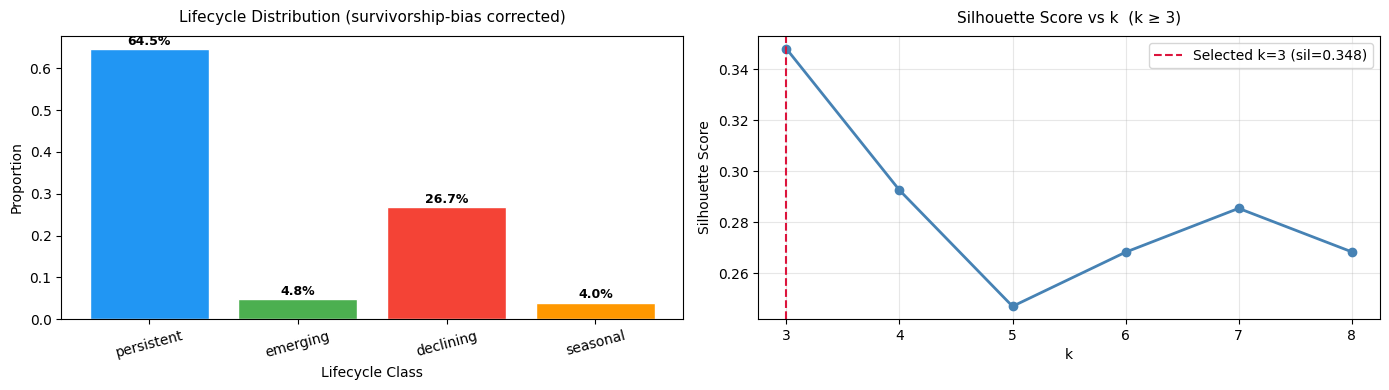

In [21]:
LC_ORDER     = ['persistent','emerging','declining','seasonal','sporadic']
LC_COLORS    = {'persistent':'#2196F3','emerging':'#4CAF50',
                'declining':'#F44336','seasonal':'#FF9800','sporadic':'#9E9E9E'}
lc_present   = [l for l in LC_ORDER if l in rules['lifecycle'].values]
lc_counts    = rules['lifecycle'].value_counts().to_dict()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = [lc_counts.get(l, 0) for l in lc_present]
props  = [c / len(rules) for c in counts]
bars   = axes[0].bar(lc_present, props, color=[LC_COLORS[l] for l in lc_present], edgecolor='white')
for bar, p in zip(bars, props):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{p:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Lifecycle Distribution (survivorship-bias corrected)', fontsize=11, pad=10)
axes[0].set_xlabel('Lifecycle Class'); axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=15)

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()),
             marker='o', color='steelblue', linewidth=2)
axes[1].axvline(best_k, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Selected k={best_k} (sil={sil_scores[best_k]:.3f})')
axes[1].set_title('Silhouette Score vs k  (k ≥ 3)', fontsize=11, pad=10)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_lifecycle_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 2 — Monthly Support Trajectories by Lifecycle

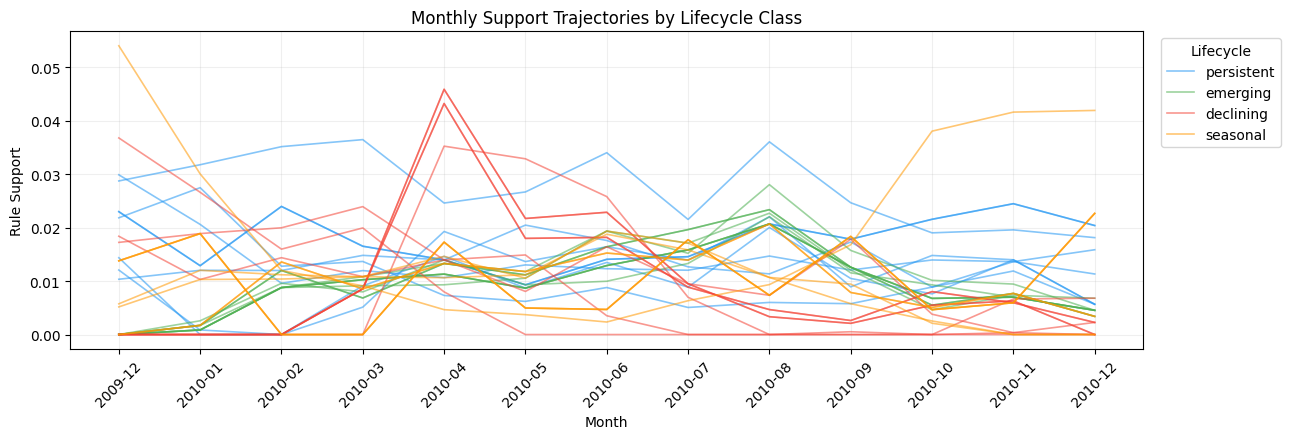

In [22]:
fig, ax = plt.subplots(figsize=(13, 4.5))
plotted = set()
for lc, color in LC_COLORS.items():
    subset = rules[rules['lifecycle'] == lc]
    if len(subset) == 0: continue
    for idx in subset.index[:8]:
        s  = monthly_support[idx]
        xs = sorted(s.keys())
        ys = [s[x] for x in xs]
        ax.plot(xs, ys, color=color, alpha=0.55, linewidth=1.2,
                label=lc if lc not in plotted else None)
        plotted.add(lc)
ax.set_title('Monthly Support Trajectories by Lifecycle Class', fontsize=12)
ax.set_xlabel('Month'); ax.set_ylabel('Rule Support')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Lifecycle', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig2_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 — Fragility Distribution & Boxplot by Lifecycle

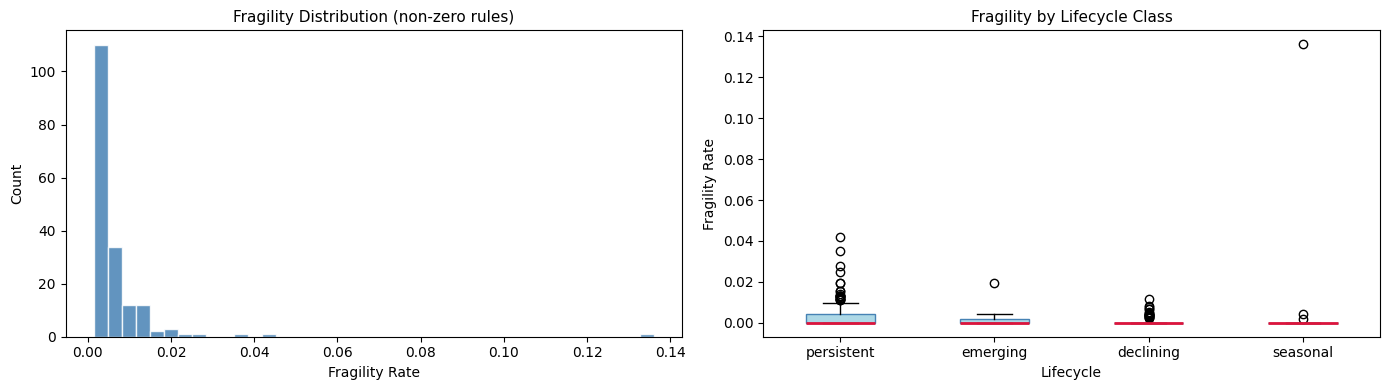

In [23]:
def lc_cat(df_in):
    out = df_in.copy()
    out['lifecycle'] = pd.Categorical(out['lifecycle'], categories=lc_present, ordered=True)
    return out

rules_cat = lc_cat(rules)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

nzf = rules['fragility'][rules['fragility'] > 0]
if len(nzf):
    axes[0].hist(nzf, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Fragility Distribution (non-zero rules)', fontsize=11)
axes[0].set_xlabel('Fragility Rate'); axes[0].set_ylabel('Count')

_lc_groups = [rules_cat[rules_cat['lifecycle']==lc]['fragility'].dropna().values
              for lc in lc_present]
_bp = axes[1].boxplot(_lc_groups, labels=lc_present, patch_artist=True)
for patch in _bp['boxes']:
    patch.set_facecolor('lightblue'); patch.set_edgecolor('steelblue')
for median in _bp['medians']:
    median.set_color('crimson'); median.set_linewidth(2)
axes[1].set_title('Fragility by Lifecycle Class', fontsize=11)
axes[1].set_xlabel('Lifecycle'); axes[1].set_ylabel('Fragility Rate')
plt.tight_layout()
plt.savefig('fig3_fragility.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4 — Support vs Fragility Scatter

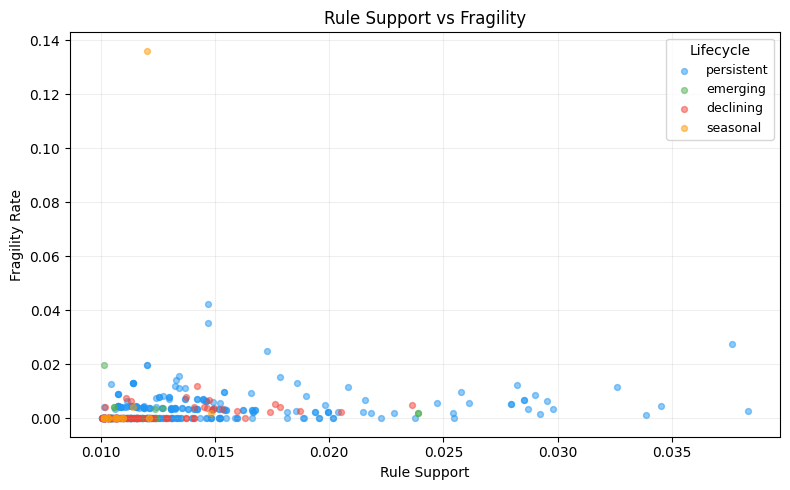

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
for lc in lc_present:
    sub = rules[rules['lifecycle'] == lc]
    ax.scatter(sub['support'], sub['fragility'], label=lc,
               alpha=0.5, s=18, color=LC_COLORS.get(lc,'grey'))
ax.set_title('Rule Support vs Fragility', fontsize=12)
ax.set_xlabel('Rule Support'); ax.set_ylabel('Fragility Rate')
ax.legend(title='Lifecycle', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig4_support_fragility.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 5 — Lift vs Cramér's V vs Conviction (Multi-metric Quality)

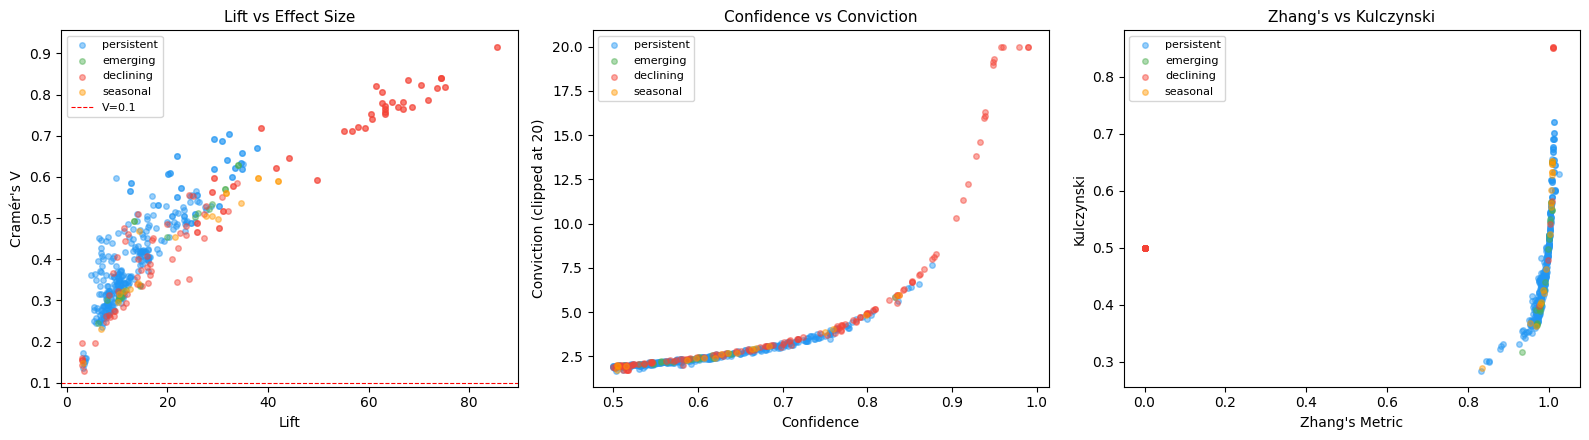

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for lc in lc_present:
    sub = rules[rules['lifecycle'] == lc]
    axes[0].scatter(sub['lift'], sub['cramers_v'], label=lc, alpha=0.45, s=16,
                    color=LC_COLORS.get(lc,'grey'))
axes[0].set_xlabel('Lift'); axes[0].set_ylabel("Cramér's V")
axes[0].set_title('Lift vs Effect Size', fontsize=11)
axes[0].axhline(CRAMERS_V_MIN, color='red', linestyle='--', linewidth=0.8, label=f'V={CRAMERS_V_MIN}')
axes[0].legend(fontsize=8)

for lc in lc_present:
    sub = rules[rules['lifecycle'] == lc]
    conv_clip = sub['conviction'].clip(upper=20)
    axes[1].scatter(sub['confidence'], conv_clip, label=lc, alpha=0.45, s=16,
                    color=LC_COLORS.get(lc,'grey'))
axes[1].set_xlabel('Confidence'); axes[1].set_ylabel('Conviction (clipped at 20)')
axes[1].set_title('Confidence vs Conviction', fontsize=11)
axes[1].legend(fontsize=8)

for lc in lc_present:
    sub = rules[rules['lifecycle'] == lc]
    axes[2].scatter(sub['zhang'], sub['kulczynski'], label=lc, alpha=0.45, s=16,
                    color=LC_COLORS.get(lc,'grey'))
axes[2].set_xlabel("Zhang's Metric"); axes[2].set_ylabel('Kulczynski')
axes[2].set_title("Zhang's vs Kulczynski", fontsize=11)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig5_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6 — Domestic vs Export Comparison

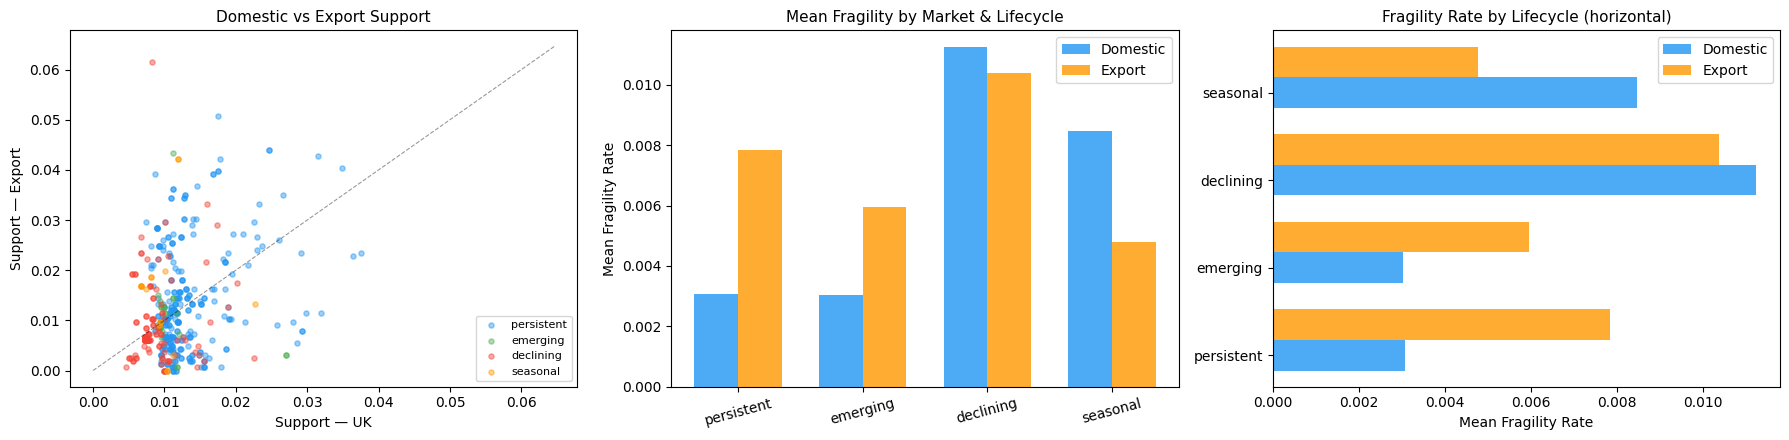

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for lc in lc_present:
    sub = rules[rules['lifecycle'] == lc]
    axes[0].scatter(sub['support_domestic'], sub['support_export'],
                    label=lc, alpha=0.45, s=14, color=LC_COLORS.get(lc,'grey'))
lim = max(rules['support_domestic'].max(), rules['support_export'].max()) * 1.05
axes[0].plot([0,lim],[0,lim],'k--', linewidth=0.8, alpha=0.4)
axes[0].set_title('Domestic vs Export Support', fontsize=11)
axes[0].set_xlabel('Support — UK'); axes[0].set_ylabel('Support — Export')
axes[0].legend(fontsize=8)

x = np.arange(len(lc_present)); w = 0.35
df_f = [rules[rules['lifecycle']==l]['fragility_domestic'].mean() for l in lc_present]
ex_f = [rules[rules['lifecycle']==l]['fragility_export'].mean()   for l in lc_present]
axes[1].bar(x-w/2, df_f, w, label='Domestic', color='#2196F3', alpha=0.8)
axes[1].bar(x+w/2, ex_f, w, label='Export',   color='#FF9800', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(lc_present, rotation=15)
axes[1].set_title('Mean Fragility by Market & Lifecycle', fontsize=11)
axes[1].set_ylabel('Mean Fragility Rate'); axes[1].legend()

dom_means = rules.groupby('lifecycle')['fragility_domestic'].mean().reindex(lc_present)
exp_means = rules.groupby('lifecycle')['fragility_export'].mean().reindex(lc_present)
axes[2].barh(lc_present, dom_means.values, 0.35, label='Domestic', color='#2196F3', alpha=0.8)
axes[2].barh([i+0.35 for i in range(len(lc_present))], exp_means.values, 0.35,
             label='Export', color='#FF9800', alpha=0.8)
axes[2].set_title('Fragility Rate by Lifecycle (horizontal)', fontsize=11)
axes[2].set_xlabel('Mean Fragility Rate'); axes[2].legend()

plt.tight_layout()
plt.savefig('fig6_domestic_export.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 7 — Temporal Jaccard Stability

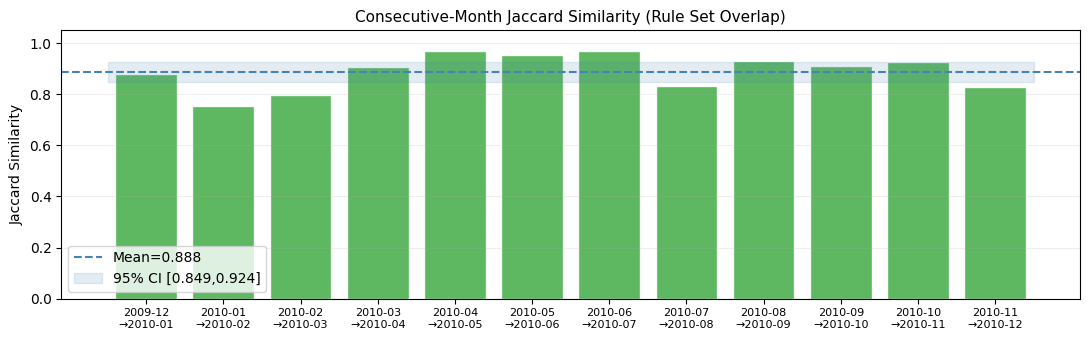

In [27]:
fig, ax = plt.subplots(figsize=(11, 3.5))
x_labels = [f"{months_available[i]}\n→{months_available[i+1]}"
            for i in range(len(months_available)-1)]
bars = ax.bar(range(len(consec_jaccard)), consec_jaccard,
              color=['#4CAF50' if j >= 0.75 else '#FF9800' for j in consec_jaccard],
              edgecolor='white', alpha=0.9)
ax.axhline(avg_j, color='steelblue', linestyle='--', linewidth=1.5, label=f'Mean={avg_j:.3f}')
ax.fill_between([-0.5, len(consec_jaccard)-0.5], ci_lo, ci_hi,
                alpha=0.15, color='steelblue', label=f'95% CI [{ci_lo:.3f},{ci_hi:.3f}]')
ax.set_xticks(range(len(x_labels))); ax.set_xticklabels(x_labels, fontsize=8)
ax.set_title('Consecutive-Month Jaccard Similarity (Rule Set Overlap)', fontsize=11)
ax.set_ylabel('Jaccard Similarity'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('fig7_jaccard.png', dpi=150, bbox_inches='tight')
plt.show()

## 22 · Business Recommendations with Specific Product Examples


In [28]:
COLS = ['ante_name','cons_name','support','confidence','lift','fragility','lifecycle']

print("=" * 72)
print("RECOMMENDATION 1 — Core bundle engine (persistent, low-fragility rules)")
print("=" * 72)
core = rules[
    (rules['lifecycle'] == 'persistent') &
    (rules['fragility'] <= rules['fragility'].quantile(0.25))
].sort_values('support', ascending=False)
display(core[COLS].head(5).reset_index(drop=True))
print("\n→ These bundles are stable year-round and rarely cancelled — safe to use as")
print("  homepage cross-sell widgets and email recommendation blocks.")
print("  Note: ranked by SUPPORT not lift, since §15 shows lift is a poor")
print("  out-of-sample proxy on this dataset.\n")

print("=" * 72)
print("RECOMMENDATION 2 — Remove from recommendation engine (high-fragility, declining)")
print("=" * 72)
remove = rules[
    (rules['lifecycle'] == 'declining') &
    (rules['is_fragile'] == True)
].sort_values('fragility', ascending=False)
display(remove[COLS].head(5).reset_index(drop=True))
print("\n→ These bundles are both shrinking in demand and frequently cancelled.")
print("  Promoting them generates returns overhead. Filter from rec-engine immediately.\n")

print("=" * 72)
print("RECOMMENDATION 3 — Watch list (emerging rules — rising demand signals)")
print("=" * 72)
emerging = rules[rules['lifecycle'] == 'emerging'].sort_values('support', ascending=False)
display(emerging[COLS].head(5).reset_index(drop=True))
print("\n→ These bundles show accelerating co-purchase growth in the second half of the")
print("  period. Consider early promotional bundling before they hit peak.\n")

print("=" * 72)
print("RECOMMENDATION 4 — Export-specific rules (higher support abroad than UK)")
print("=" * 72)
if 'support_export' in rules.columns and 'support_domestic' in rules.columns:
    export_bias = rules[rules['support_export'] > rules['support_domestic'] * 1.5].sort_values('support_export', ascending=False)
    display(export_bias[COLS + ['support_domestic','support_export']].head(5).reset_index(drop=True))
    print("\n→ These bundles are significantly more popular outside the UK. Use them on")
    print("  international storefronts; they may reflect different gift-giving customs.\n")

print("=" * 72)
print("RECOMMENDATION 5 — Avoid seasonal rules outside their peak window")
print("=" * 72)
seasonal = rules[rules['lifecycle'] == 'seasonal'].sort_values('lift', ascending=False)
display(seasonal[COLS].head(5).reset_index(drop=True))
print("\n→ These rules have high CV (irregular support spikes). Only activate them during")
print("  their historically active months; leave-always-on will dilute click-through rates.")

RECOMMENDATION 1 — Core bundle engine (persistent, low-fragility rules)


,ante_name,cons_name,support,confidence,lift,fragility,lifecycle
0,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN,0.025468,0.500626,9.089975,0.000000,persistent
1,PACK OF 72 SKULL CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.023749,0.617550,6.883772,0.000000,persistent
2,PACK OF 60 DINOSAUR CAKE CASES,PACK OF 72 RETRO SPOT CAKE CASES,0.022284,0.638686,7.119379,0.000000,persistent
3,TOILET METAL SIGN,BATHROOM METAL SIGN,0.020183,0.728736,20.221770,0.000000,persistent
4,BATHROOM METAL SIGN,TOILET METAL SIGN,0.020183,0.560071,20.221770,0.000000,persistent



→ These bundles are stable year-round and rarely cancelled — safe to use as
  homepage cross-sell widgets and email recommendation blocks.
  Note: ranked by SUPPORT not lift, since §15 shows lift is a poor
  out-of-sample proxy on this dataset.

RECOMMENDATION 2 — Remove from recommendation engine (high-fragility, declining)


,ante_name,cons_name,support,confidence,lift,fragility,lifecycle
0,RED SPOTTY BOWL,BLUE SPOTTY BOWL,0.014188,0.507937,25.179138,0.011858,declining
1,"RED SPOTTY CHARLOTTE BAG + CHARLOTTE BAG , PINK/WHITE SPOTS",JUMBO BAG RED RETROSPOT,0.013744,0.502024,5.626414,0.008032,declining
2,LUNCH BAG RED SPOTTY + LUNCH BAG WOODLAND,LUNCH BAG BLACK SKULL.,0.011084,0.512821,10.123997,0.007547,declining



→ These bundles are both shrinking in demand and frequently cancelled.
  Promoting them generates returns overhead. Filter from rec-engine immediately.

RECOMMENDATION 3 — Watch list (emerging rules — rising demand signals)


...


→ These bundles show accelerating co-purchase growth in the second half of the
  period. Consider early promotional bundling before they hit peak.

RECOMMENDATION 4 — Export-specific rules (higher support abroad than UK)


,ante_name,cons_name,support,confidence,lift,fragility,lifecycle,support_domestic,support_export
0,ROUND SNACK BOXES SET OF 4 FRUITS,ROUND SNACK BOXES SET OF4 WOODLAND,0.014963,0.529412,14.257770,0.003717,declining,0.008287,0.061520
1,WOODLAND CHARLOTTE BAG,RED SPOTTY CHARLOTTE BAG,0.021584,0.573604,11.476465,0.006881,persistent,0.017467,0.050663
2,"CHARLOTTE BAG , PINK/WHITE SPOTS",RED SPOTTY CHARLOTTE BAG,0.027951,0.639942,12.803725,0.005254,persistent,0.024712,0.044029
3,RED SPOTTY CHARLOTTE BAG,"CHARLOTTE BAG , PINK/WHITE SPOTS",0.027951,0.559236,12.803725,0.005254,persistent,0.024712,0.044029
4,PLASTERS IN TIN WOODLAND ANIMALS,PLASTERS IN TIN SPACEBOY,0.012352,0.513228,19.952355,0.003356,emerging,0.011215,0.043426



→ These bundles are significantly more popular outside the UK. Use them on
  international storefronts; they may reflect different gift-giving customs.

RECOMMENDATION 5 — Avoid seasonal rules outside their peak window


,ante_name,cons_name,support,confidence,lift,fragility,lifecycle
0,BLUE SPOTTY CUP + RED SPOTTY CUP,GREEN SPOTTY CUP,0.010124,0.668067,41.970655,0.000000,seasonal
1,GREEN SPOTTY CUP,BLUE SPOTTY CUP + RED SPOTTY CUP,0.010124,0.636000,41.970655,0.000000,seasonal
2,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.010951,0.627737,38.066567,0.000000,seasonal
3,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.010951,0.664093,38.066567,0.000000,seasonal
4,GREEN SPOTTY CUP + RED SPOTTY CUP,BLUE SPOTTY CUP,0.010124,0.832461,34.680712,0.000000,seasonal



→ These rules have high CV (irregular support spikes). Only activate them during
  their historically active months; leave-always-on will dilute click-through rates.
